# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Childhood Stunting Dataset](https://www.kaggle.com/datasets/victoriahayes/stunting-toddler-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Childhood_Stunting_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Gender,Child_Age,Birth_Weight,Birth_Length,Mother_Age,Mother_Height,Mother_Education,ANC_Visits,Exclusive_Breastfeeding,Complementary_Feeding_Age,Dietary_Diversity_Score,Immunization_Status,Recent_Diarrhea,Residence_Type,Drinking_Water_Source,Sanitation_Facility,Distance_to_Health_Center_km,Household_Size,Wealth_Index,Stunting_Status
0,Female,43,3.07,48.7,21,154.4,Secondary,10,No,8.0,2,Complete,Yes,Rural,Protected,Improved,32.74,4,Medium,Severely Stunted
1,Female,7,3.14,49.9,45,150.7,Secondary,10,Yes,6.0,4,Partial,Yes,Rural,Protected,Improved,21.07,8,High,Normal
2,Male,16,3.00,50.2,36,155.3,Higher,7,Yes,6.0,4,Complete,No,Rural,Protected,Improved,16.90,5,Low,Normal
3,Male,22,3.12,53.4,27,160.3,No Education,4,No,7.0,6,Partial,No,Rural,Protected,Unimproved,35.07,3,High,Normal
4,Female,54,2.49,49.7,27,150.1,No Education,3,No,4.0,2,Partial,No,Urban,Protected,Improved,0.22,10,Medium,Stunted


## last Five row

In [4]:
df.tail()

,Gender,Child_Age,Birth_Weight,Birth_Length,Mother_Age,Mother_Height,Mother_Education,ANC_Visits,Exclusive_Breastfeeding,Complementary_Feeding_Age,Dietary_Diversity_Score,Immunization_Status,Recent_Diarrhea,Residence_Type,Drinking_Water_Source,Sanitation_Facility,Distance_to_Health_Center_km,Household_Size,Wealth_Index,Stunting_Status
2988,Female,44,2.90,50.5,35,151.9,Primary,7,Yes,6.0,4,Complete,Yes,Urban,Protected,Improved,7.26,8,Medium,Normal
2989,Male,25,2.70,51.1,21,153.0,Primary,2,Yes,5.0,1,Complete,No,Rural,Protected,Improved,16.28,2,Medium,Normal
2990,Female,8,2.00,46.0,44,144.3,Primary,7,No,6.0,6,Complete,No,Rural,Protected,Improved,18.15,2,Medium,Normal
2991,Female,43,2.30,49.2,38,153.4,Primary,8,No,7.0,4,Complete,No,Urban,Protected,Improved,25.44,7,Medium,Stunted
2992,Female,35,4.01,52.1,20,150.6,Primary,2,Yes,7.0,2,Partial,Yes,Urban,Protected,Improved,21.20,2,Low,Normal


## Shape of our dataset

In [5]:
df.shape

(2993, 20)

## List out all columns

In [6]:
df.columns

Index(['Gender', 'Child_Age', 'Birth_Weight', 'Birth_Length', 'Mother_Age',
       'Mother_Height', 'Mother_Education', 'ANC_Visits',
       'Exclusive_Breastfeeding', 'Complementary_Feeding_Age',
       'Dietary_Diversity_Score', 'Immunization_Status', 'Recent_Diarrhea',
       'Residence_Type', 'Drinking_Water_Source', 'Sanitation_Facility',
       'Distance_to_Health_Center_km', 'Household_Size', 'Wealth_Index',
       'Stunting_Status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Gender                           object
Child_Age                         int64
Birth_Weight                    float64
Birth_Length                    float64
Mother_Age                        int64
Mother_Height                   float64
Mother_Education                 object
ANC_Visits                        int64
Exclusive_Breastfeeding          object
Complementary_Feeding_Age       float64
Dietary_Diversity_Score           int64
Immunization_Status              object
Recent_Diarrhea                  object
Residence_Type                   object
Drinking_Water_Source            object
Sanitation_Facility              object
Distance_to_Health_Center_km    float64
Household_Size                    int64
Wealth_Index                     object
Stunting_Status                  object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2993 entries, 0 to 2992
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Gender                        2993 non-null   object 
 1   Child_Age                     2993 non-null   int64  
 2   Birth_Weight                  2932 non-null   float64
 3   Birth_Length                  2910 non-null   float64
 4   Mother_Age                    2993 non-null   int64  
 5   Mother_Height                 2993 non-null   float64
 6   Mother_Education              2993 non-null   object 
 7   ANC_Visits                    2993 non-null   int64  
 8   Exclusive_Breastfeeding       2993 non-null   object 
 9   Complementary_Feeding_Age     2956 non-null   float64
 10  Dietary_Diversity_Score       2993 non-null   int64  
 11  Immunization_Status           2993 non-null   object 
 12  Recent_Diarrhea               2993 non-null   object 
 13  Res

## Check Null Value

In [9]:
df.isnull().sum()

Gender                           0
Child_Age                        0
Birth_Weight                    61
Birth_Length                    83
Mother_Age                       0
Mother_Height                    0
Mother_Education                 0
ANC_Visits                       0
Exclusive_Breastfeeding          0
Complementary_Feeding_Age       37
Dietary_Diversity_Score          0
Immunization_Status              0
Recent_Diarrhea                  0
Residence_Type                   0
Drinking_Water_Source            0
Sanitation_Facility              0
Distance_to_Health_Center_km     0
Household_Size                   0
Wealth_Index                     0
Stunting_Status                  0
dtype: int64

## Handle Null Features

In [10]:
df['Birth_Weight'] = df['Birth_Weight'].fillna(df['Birth_Weight'].mean())
df['Birth_Length'] = df['Birth_Length'].fillna(df['Birth_Length'].mean())
df['Complementary_Feeding_Age'] = df['Complementary_Feeding_Age'].fillna(df['Complementary_Feeding_Age'].mean())

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Child_Age,Birth_Weight,Birth_Length,Mother_Age,Mother_Height,ANC_Visits,Complementary_Feeding_Age,Dietary_Diversity_Score,Distance_to_Health_Center_km,Household_Size
count,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000
mean,29.637153,3.095662,50.771134,30.306047,151.686101,4.988306,6.020636,4.521216,20.224053,5.929502
std,17.101986,0.537430,1.868057,8.726490,5.719876,3.157232,1.405649,2.326529,11.453202,2.572747
min,1.000000,1.600000,43.700000,16.000000,132.700000,0.000000,4.000000,1.000000,0.220000,2.000000
25%,15.000000,2.750000,49.600000,23.000000,147.900000,2.000000,5.000000,2.000000,10.360000,4.000000
50%,29.000000,3.095662,50.771134,30.000000,151.600000,5.000000,6.000000,5.000000,20.060000,6.000000
75%,44.000000,3.450000,52.000000,38.000000,155.400000,8.000000,7.000000,7.000000,30.100000,8.000000
max,59.000000,4.920000,55.000000,45.000000,172.000000,10.000000,8.000000,8.000000,39.990000,10.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

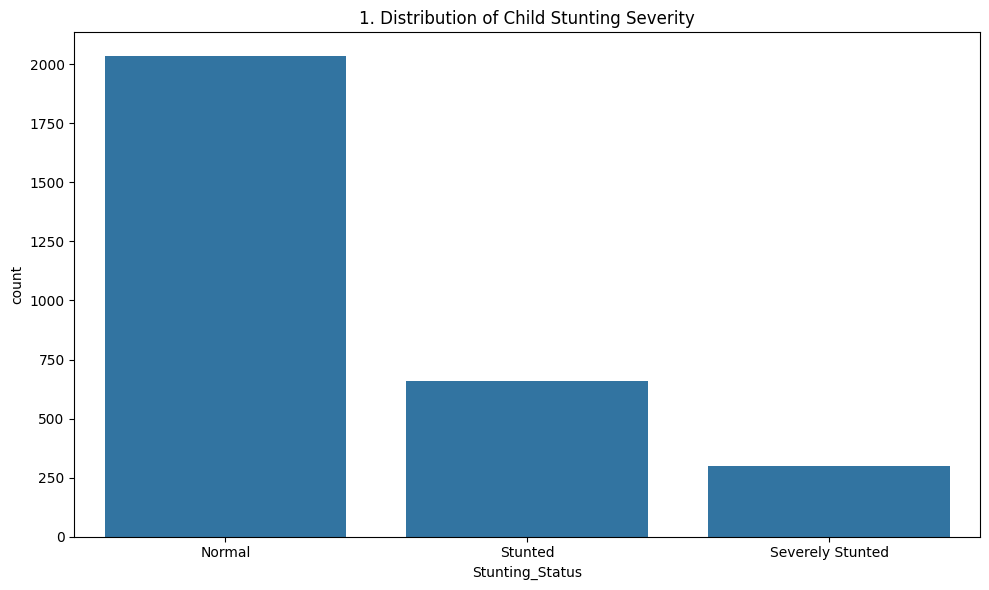

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Stunting_Status', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Child Stunting Severity')
show_fig()
plot_no += 1

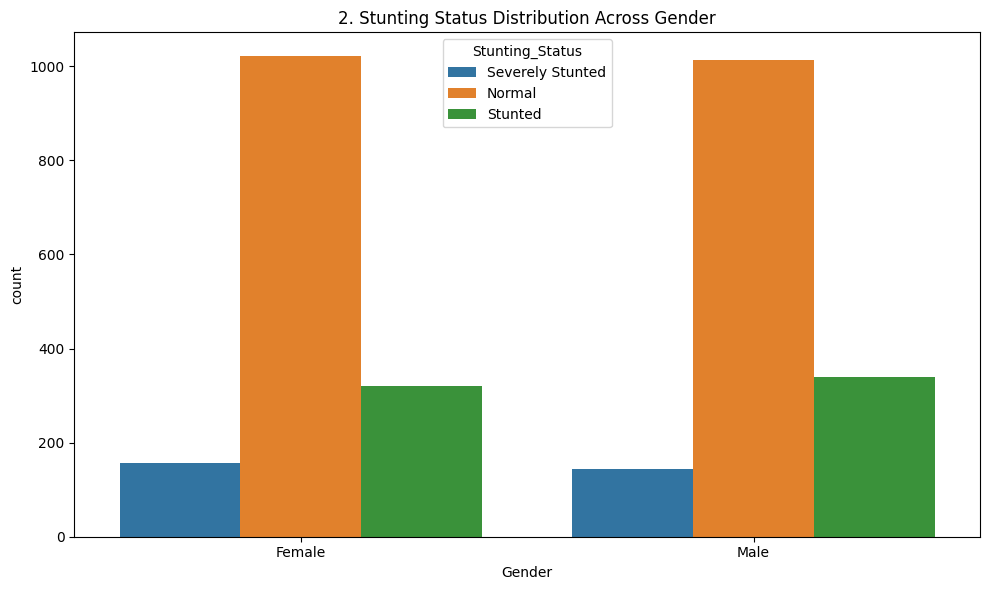

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Stunting_Status')
plt.title(f'{plot_no}. Stunting Status Distribution Across Gender')
show_fig()
plot_no += 1

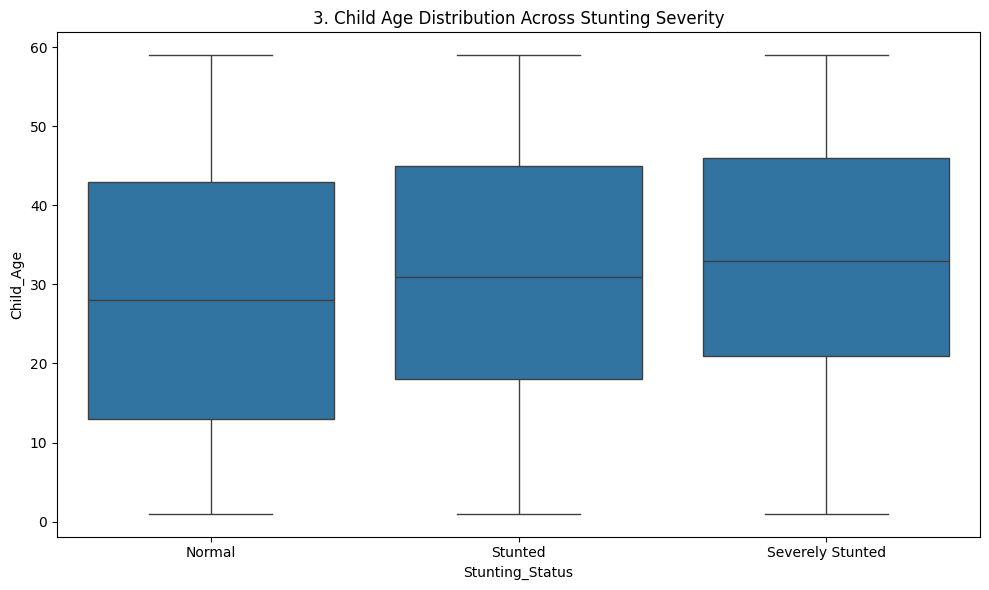

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Child_Age', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Child Age Distribution Across Stunting Severity')
show_fig()
plot_no += 1

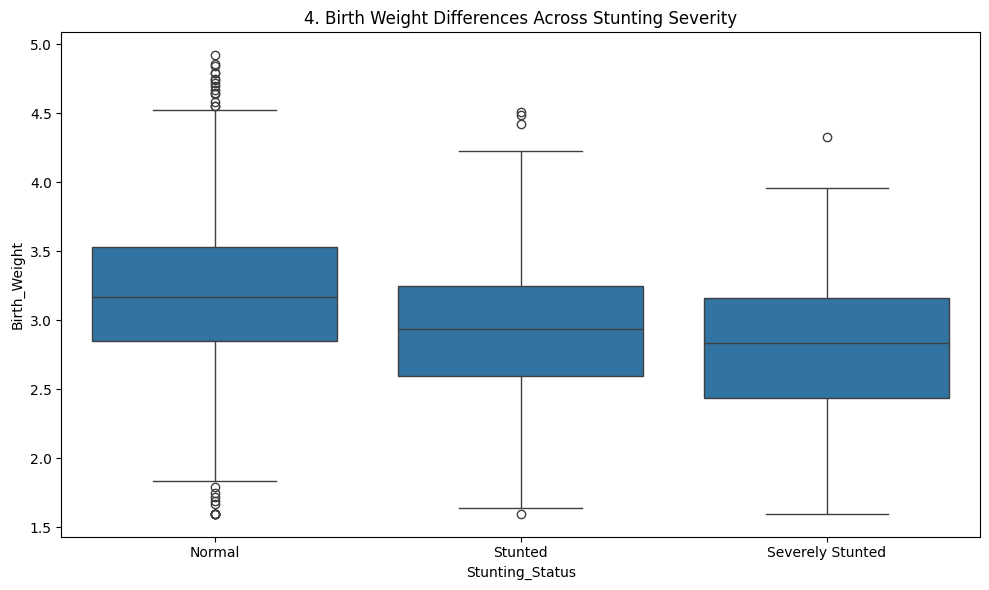

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Birth_Weight', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Birth Weight Differences Across Stunting Severity')
show_fig()
plot_no += 1

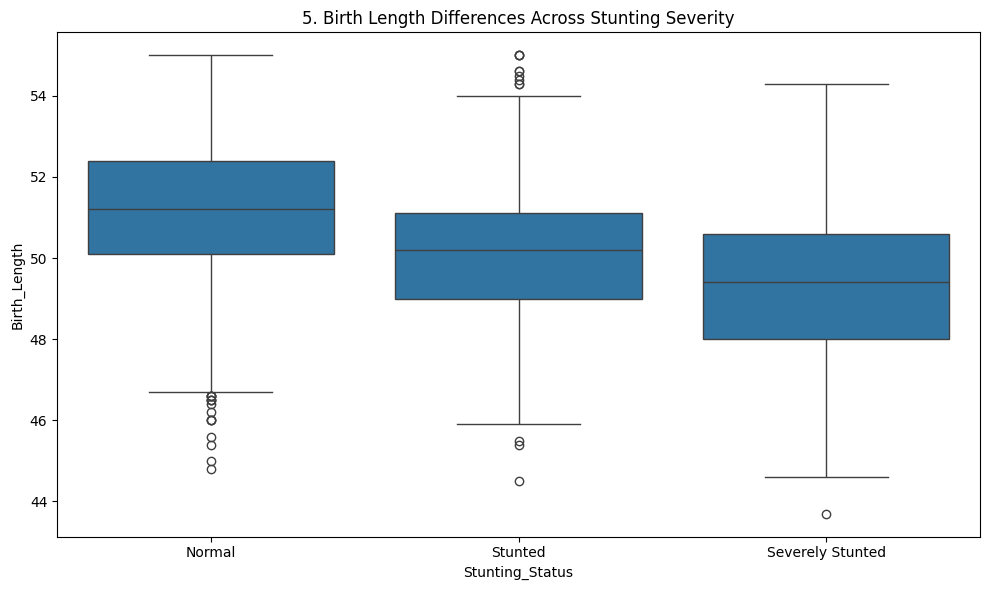

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Birth_Length', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Birth Length Differences Across Stunting Severity')
show_fig()
plot_no += 1

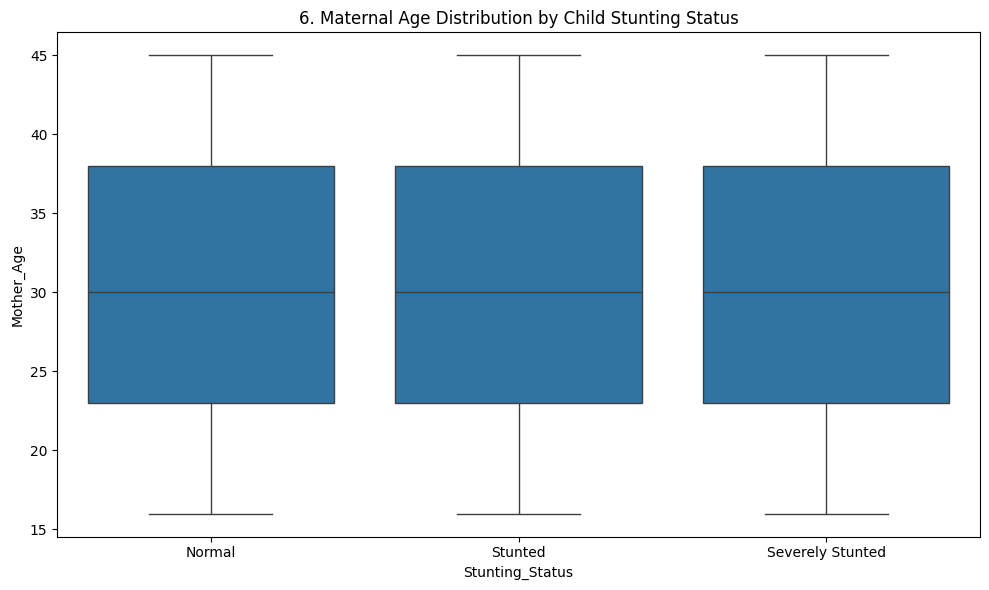

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Mother_Age', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Maternal Age Distribution by Child Stunting Status')
show_fig()
plot_no += 1

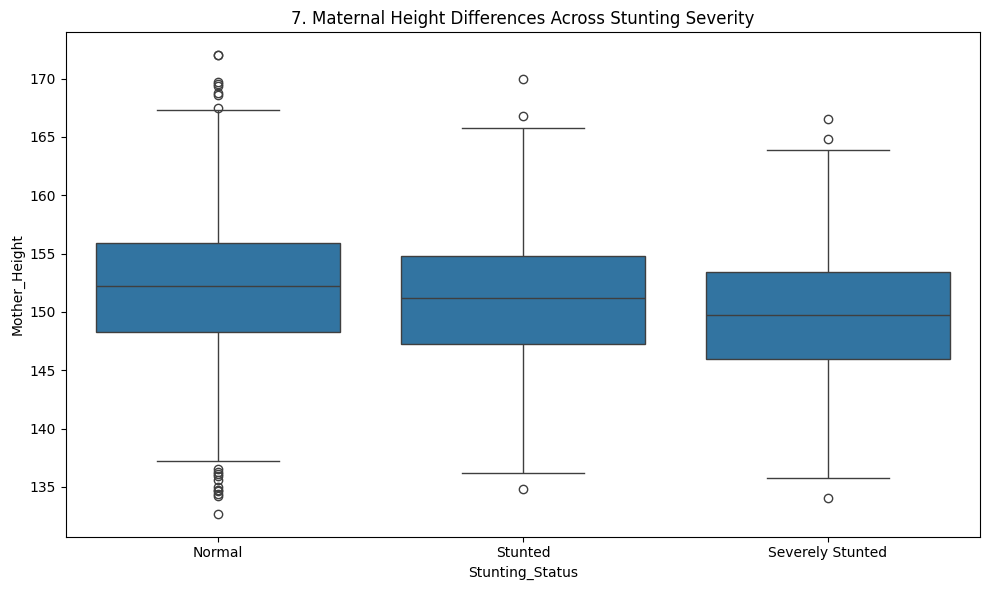

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Mother_Height', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Maternal Height Differences Across Stunting Severity')
show_fig()
plot_no += 1

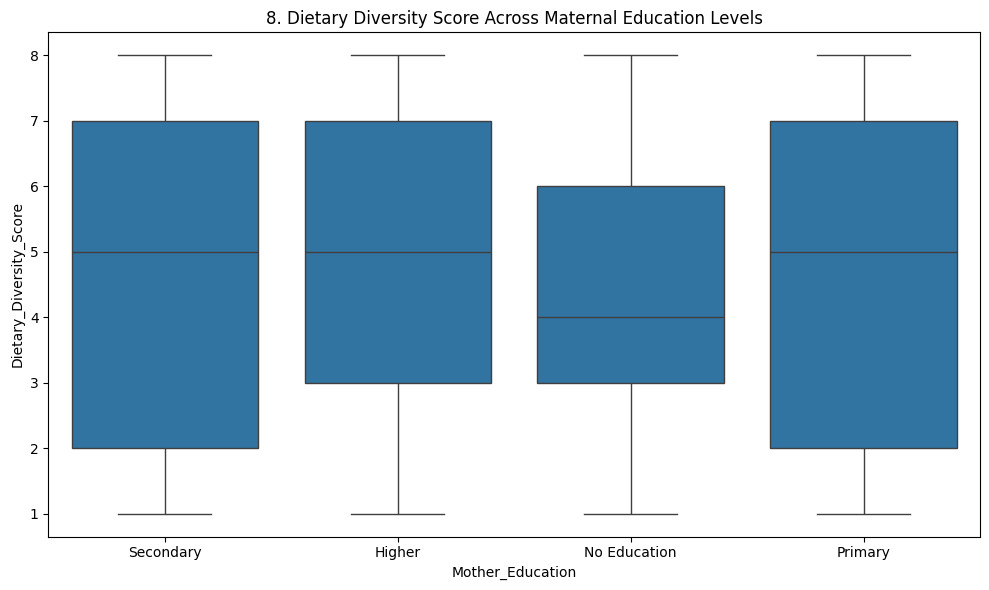

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Mother_Education', y='Dietary_Diversity_Score')
plt.title(f'{plot_no}. Dietary Diversity Score Across Maternal Education Levels')
show_fig()
plot_no += 1

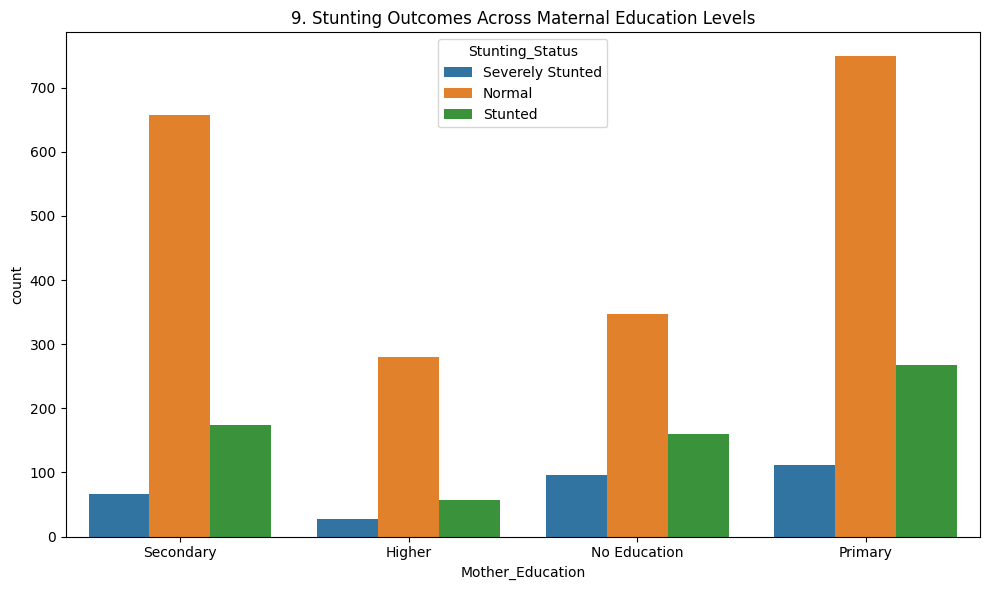

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Mother_Education', hue='Stunting_Status')
plt.title(f'{plot_no}. Stunting Outcomes Across Maternal Education Levels')
show_fig()
plot_no += 1

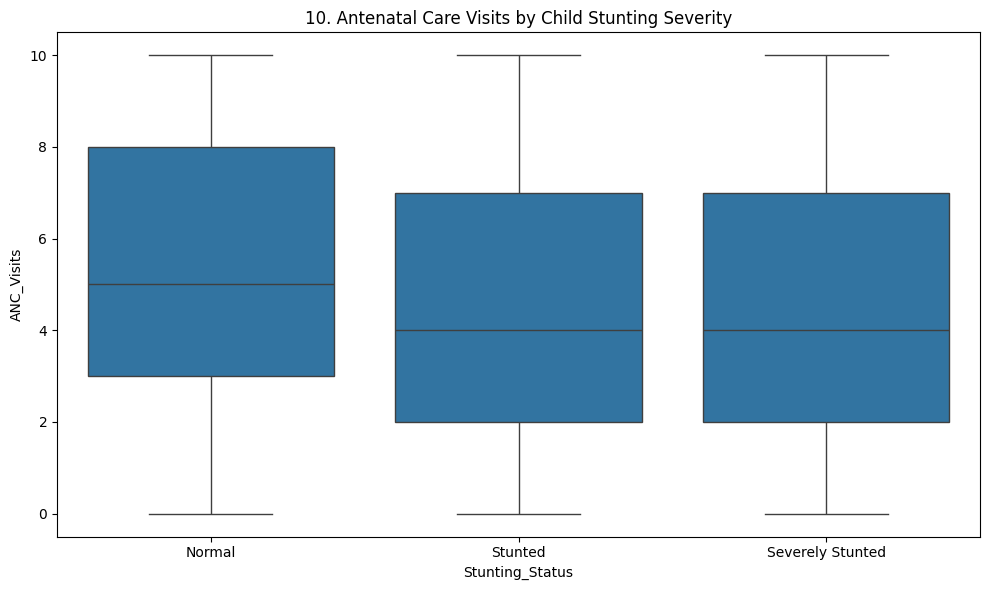

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='ANC_Visits', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Antenatal Care Visits by Child Stunting Severity')
show_fig()
plot_no += 1

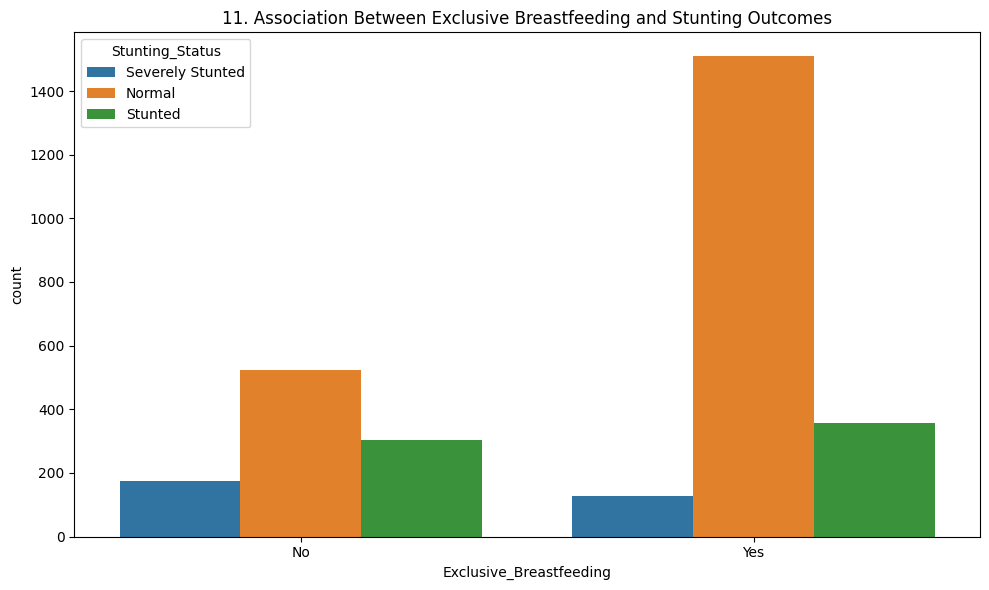

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Exclusive_Breastfeeding', hue='Stunting_Status')
plt.title(f'{plot_no}. Association Between Exclusive Breastfeeding and Stunting Outcomes')
show_fig()
plot_no += 1

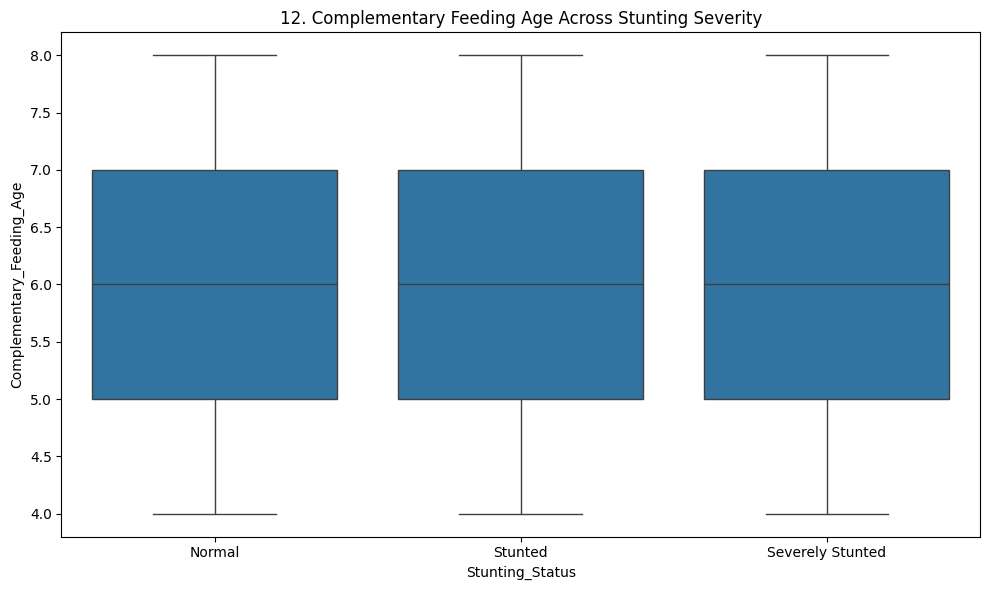

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Complementary_Feeding_Age', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Complementary Feeding Age Across Stunting Severity')
show_fig()
plot_no += 1

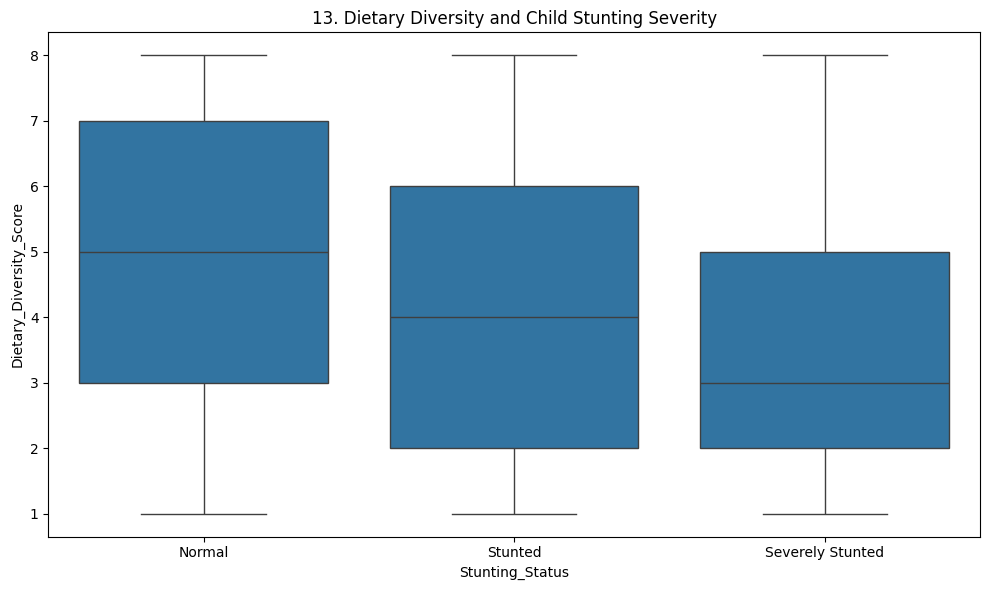

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Dietary_Diversity_Score', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Dietary Diversity and Child Stunting Severity')
show_fig()
plot_no += 1

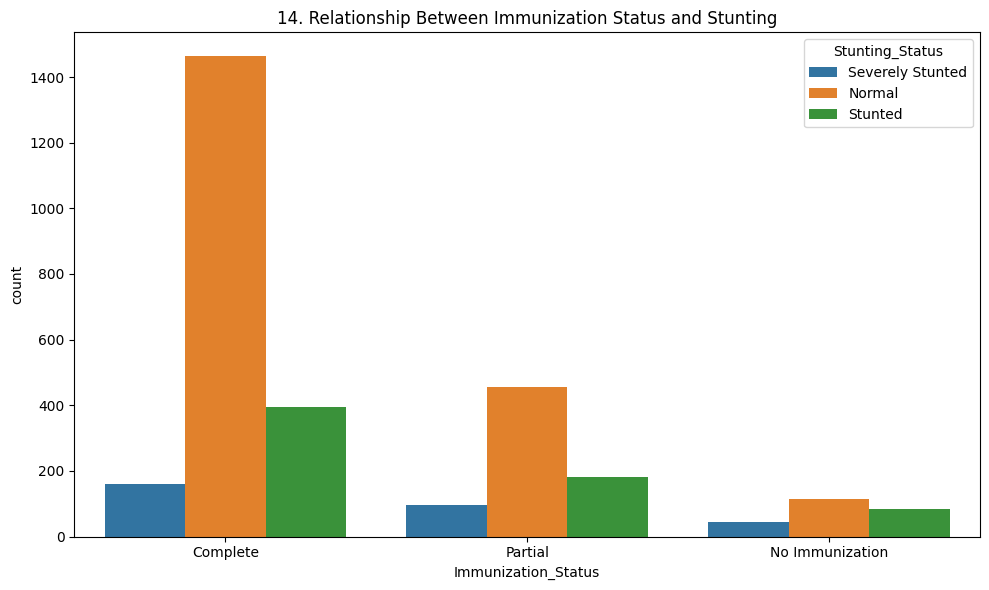

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Immunization_Status', hue='Stunting_Status')
plt.title(f'{plot_no}. Relationship Between Immunization Status and Stunting')
show_fig()
plot_no += 1

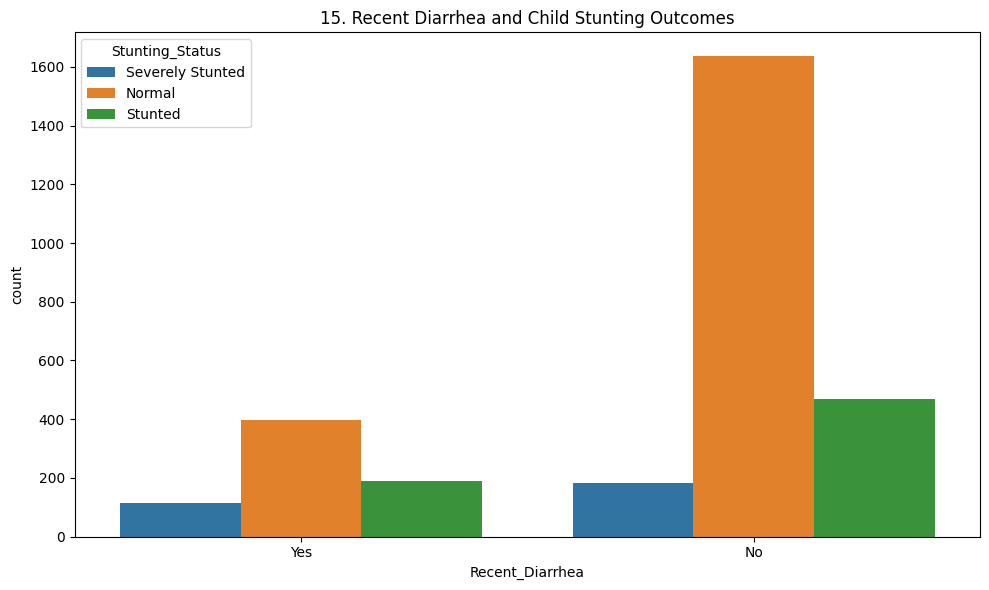

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Recent_Diarrhea', hue='Stunting_Status')
plt.title(f'{plot_no}. Recent Diarrhea and Child Stunting Outcomes')
show_fig()
plot_no += 1

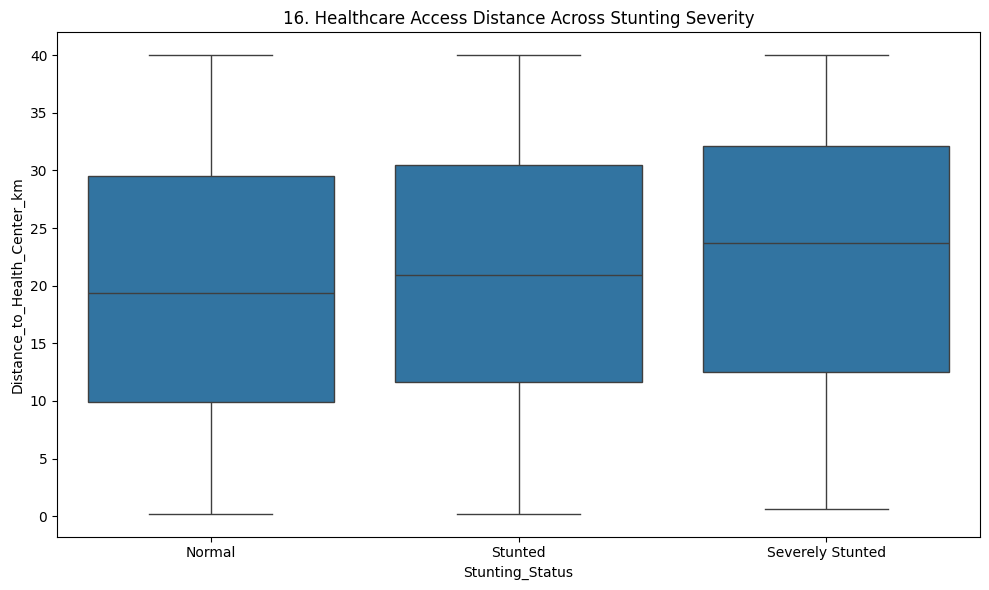

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Stunting_Status', y='Distance_to_Health_Center_km', order=df['Stunting_Status'].value_counts().index)
plt.title(f'{plot_no}. Healthcare Access Distance Across Stunting Severity')
show_fig()
plot_no += 1

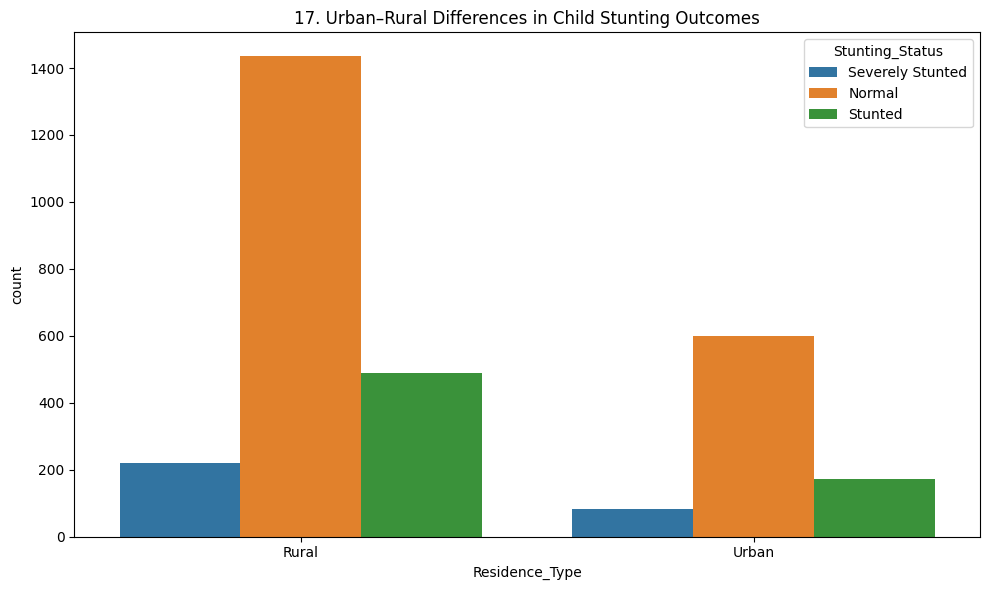

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Residence_Type', hue='Stunting_Status')
plt.title(f'{plot_no}. Urban–Rural Differences in Child Stunting Outcomes')
show_fig()
plot_no += 1

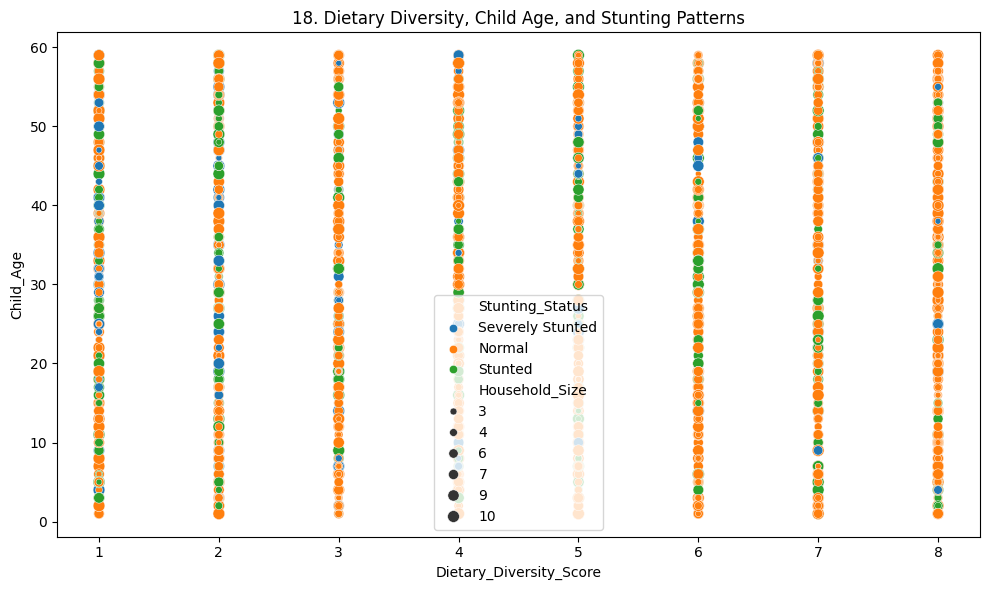

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Dietary_Diversity_Score', y='Child_Age', hue='Stunting_Status', size='Household_Size')
plt.title(f'{plot_no}. Dietary Diversity, Child Age, and Stunting Patterns')
show_fig()
plot_no += 1

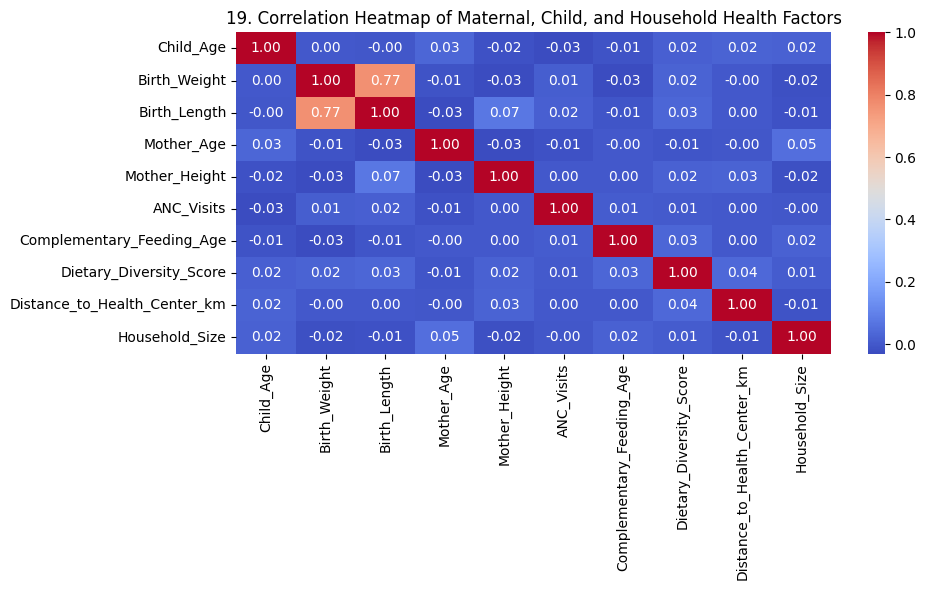

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Maternal, Child, and Household Health Factors')
show_fig()
plot_no += 1

# Model Training

## Prepare data

In [33]:
X = df.drop('Stunting_Status', axis=1)
y = df['Stunting_Status']

## Identify columns

In [34]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

## Preprocess numerical and categorical features

In [35]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

## Split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train Gradient Boosting model

In [37]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.9,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [38]:
y_pred = model.predict(X_test)

## Print accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

Accuracy: 71.95%
                  precision    recall  f1-score   support

          Normal       0.79      0.91      0.85       407
Severely Stunted       0.56      0.32      0.40        60
         Stunted       0.42      0.31      0.36       132

        accuracy                           0.72       599
       macro avg       0.59      0.51      0.54       599
    weighted avg       0.69      0.72      0.70       599



## Plot confusion matrix

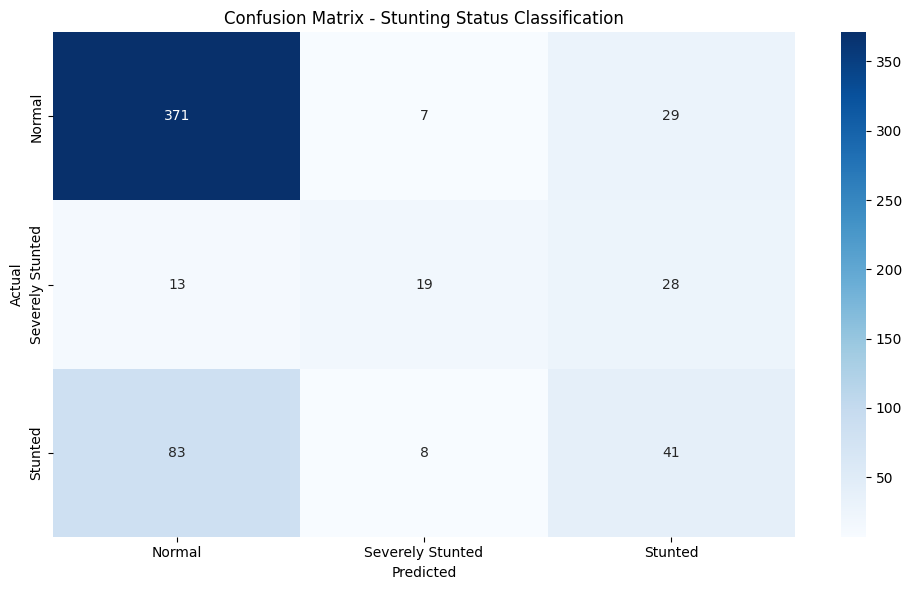

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Stunting Status Classification')
plt.tight_layout()
plt.show()